In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
import os

In [24]:
# Place this in a code cell at the top of your notebook (Section 0)
DATA_DIR = "."
OUT_DIR = "."

MIN_LEN = 50
MAX_N_RATIO = 0.05  
WINDOW_SIZE = 200
WINDOW_STRIDE = 50
MAJORITY_CAP = 1500
RANDOM_STATE = 42

In [25]:
Dogs = pd.read_csv(r"D:\TECH405\DNASequences\DataSets\dog.txt", sep="\t")
Dogs['class'] = 'Canis lupus'  # or 'Dog'
Dogs.to_csv("dog.csv", index=False)
print(Dogs)


Humans = pd.read_csv(r"D:\TECH405\DNASequences\DataSets\human.txt", sep= '\t')
Humans['class'] = 'Homo sapiens'
Humans.to_csv("human.csv", index=False)
print(Humans)


Chimpange = pd.read_csv(r"D:\TECH405\DNASequences\DataSets\chimpanzee.txt", sep='\t')
Chimpange['class'] = 'Pan troglodytes'
Chimpange.to_csv("Chimp.csv", index=False)
print(Chimpange)


                                              sequence        class
0    ATGCCACAGCTAGATACATCCACCTGATTTATTATAATCTTTTCAA...  Canis lupus
1    ATGAACGAAAATCTATTCGCTTCTTTCGCTGCCCCCTCAATAATAG...  Canis lupus
2    ATGGAAACACCCTTCTACGGCGATGAGGCGCTGAGCGGCCTGGGCG...  Canis lupus
3    ATGTGCACTAAAATGGAACAGCCCTTCTACCACGACGACTCATACG...  Canis lupus
4    ATGAGCCGGCAGCTAAACAGAAGCCAGAACTGCTCCTTCAGTGACG...  Canis lupus
..                                                 ...          ...
815  ATGGTCGGTCCGGAGAAGGAGCAGAGCTGGATCCCTAAGATCTTCA...  Canis lupus
816  ATGGCGGCGACGGTGGCTGCGGCGGCCGCCGACGCGGGGCCGGGGG...  Canis lupus
817  ATGAGCTCGGCCGACAAGGCCCGGGTGGGGCCCGCGGCCGACGGGC...  Canis lupus
818  GCCCCGAGGATGGGCAGGGTCCCGCTGGCCTGGTGCTTGGCGCTGT...  Canis lupus
819  ATGGCCTGGGCTCTGAAGCTGCCCCTGGCCGACGAAGTGATTGAAT...  Canis lupus

[820 rows x 2 columns]
                                               sequence         class
0     ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...  Homo sapiens
1     ATGAACGAAAATCT

In [26]:
df = pd.read_csv(r"d:\TECH405\DNASequences\DataSets\Cow.tsv", sep="\t", low_memory=False)

# Keep only the useful columns
Cow = df[['nuc', 'species']].copy()

# Rename to match your previous style
Cow = Cow.rename(columns={
    'nuc': 'sequence',
    'species': 'class'
})

# Remove rows with missing sequences
Cow = Cow.dropna(subset=['sequence'])
Cow.to_csv("cow.csv", index=False)
print(Cow.head())
print(Cow.shape)

                                            sequence       class
0  NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...  Bos taurus
1  GGTGCTTGGGCCGGTATAGTAGGAACAGCTCTAAGCCTTCTAATTC...  Bos taurus
2  CTACTATTTGGTGCTTGGGCCGGTATAGTAGGAACAGCTCTAAGCC...  Bos taurus
3  TCTAAGCCTTCTAATTCGCGCTGAATTAGGCCAACCCGGAACTCTG...  Bos taurus
4  TTCTAATTCGCGCTGAATTAGGCCAACCCGGAACTCTGCTCGGAGA...  Bos taurus
(1123, 2)


In [27]:
dfe = pd.read_csv(r"d:\TECH405\DNASequences\DataSets\Cat.tsv", sep="\t", low_memory=False)

# Keep only the useful columns
Cat = dfe[['nuc', 'species']].copy()

# Rename to match your previous style
Cat = Cat.rename(columns={
    'nuc': 'sequence',
    'species': 'class'
})

# Remove rows with missing sequences
Cat = Cat.dropna(subset=['sequence'])
Cat.to_csv("Cat.csv", index=False)
print(Cat.head())
print(Cat.shape)

                                            sequence        class
0  NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...  Felis catus
1  TCCTGCCATGTCCCAATATCAAACACCCCTATTTGTCTGATCAGTC...  Felis catus
2  TTCACTACCCCAACAATAATAGGATTACCTATTGTTATTTTAATTA...  Felis catus
3  TCCTGCCATGTCCCAATATCAAACACCCCTATTTGTCTGATCAGTC...  Felis catus
4  TTCACCACCCCAACAATAATAGGATTACCTATTGTTATTTTAATTA...  Felis catus
(58, 2)


In [28]:
# ======================
# 4. Combine everything
# ======================
DataSets = pd.concat([Dogs, Humans, Chimpange, Cow, Cat], ignore_index=True)

# Optional: remove any remaining missing sequences
DataSets= DataSets.dropna(subset=['sequence'])

# ======================
# 5. Check the result
# ======================
print("Final combined shape:", DataSets.shape)
print("\nClass distribution:")
print(DataSets['class'].value_counts())

print("\nFirst 5 rows:")
print(DataSets.head())

# ======================
# 6. Save the combined dataset
# ======================
DataSets.to_csv("all_combined_dna.csv", index=False)
print("\nSaved as → all_combined_dna.csv")

Final combined shape: (8063, 2)

Class distribution:
class
Homo sapiens       4380
Pan troglodytes    1682
Bos taurus         1123
Canis lupus         820
Felis catus          58
Name: count, dtype: int64

First 5 rows:
                                            sequence        class
0  ATGCCACAGCTAGATACATCCACCTGATTTATTATAATCTTTTCAA...  Canis lupus
1  ATGAACGAAAATCTATTCGCTTCTTTCGCTGCCCCCTCAATAATAG...  Canis lupus
2  ATGGAAACACCCTTCTACGGCGATGAGGCGCTGAGCGGCCTGGGCG...  Canis lupus
3  ATGTGCACTAAAATGGAACAGCCCTTCTACCACGACGACTCATACG...  Canis lupus
4  ATGAGCCGGCAGCTAAACAGAAGCCAGAACTGCTCCTTCAGTGACG...  Canis lupus

Saved as → all_combined_dna.csv


In [29]:
DNA = pd.read_csv("all_combined_dna.csv")

print("Shape:", DNA.shape)
print("\nColumns:", DNA.columns.tolist())
print("\nData types:\n", DNA.dtypes)
print("\n5 random samples:")
display(DNA.sample(5, random_state=42))


Shape: (8063, 2)

Columns: ['sequence', 'class']

Data types:
 sequence    str
class       str
dtype: object

5 random samples:


,sequence,class
742,ATGTCGTCCTGGACGAGGTGGCATGGACCCGCCATGGCGCGGCTCT...,Canis lupus
2126,ATGGGGACCCAACCAGAGCCTGGCCTGGGAGCCAGGATGGCCATCC...,Homo sapiens
3689,ATGGCCTGCCGAGAATTTGAGATGGGAAGGAAAAAATGTGAGCGCT...,Homo sapiens
4586,ATGCTGCGAACGTCCGTCCTCCGCCTGCTAGGACGCACGGGGGCTA...,Homo sapiens
6290,ATGATGGGGCTTCCTGAGGAGCGGGGCCGGAGCGGCAGCGGGAGCC...,Pan troglodytes


### Dataset Card

- **Source**:
  - Human, Dog, Chimpanzee (`human.txt`, `dog.txt`, `chimpanzee.txt`): Kaggle — "DNA sequence dataset" by Nagesh Singh Chauhan.
    https://www.kaggle.com/datasets/nageshsingh/dna-sequence-dataset
  - Cow (`Cow.tsv`), Cat (`Cat.tsv`): BOLD Systems (Barcode of Life Data System), COI barcode records queried by species.
    https://www.boldsystems.org — *(exact query/filter used to export these two files wasn't saved; re-run and save the query URL for reproducibility before final submission)*
- **Licence**: Kaggle dataset license should be verified on the dataset page linked above before redistribution. BOLD Systems data is generally available for non-commercial research use, but redistribution terms should be checked at boldsystems.org/index.php/resources/policies.
- **Size on disk**: run this and report the number — 11.7 MB
- **Number of samples**: 8,063 raw sequences → 6,590 after removing duplicates and sequences with >5% ambiguous ('N') bases.
- **How collected**:
  - Kaggle set: coding-region DNA sequences labeled by gene family, curated for a supervised-learning benchmark.
  - BOLD set: COI barcode sequences submitted by contributing researchers/institutions worldwide.
- **Known limitations**:
  - Severe class imbalance (Homo sapiens 54% of raw data vs. Felis catus 0.7%).
  - Ambiguous bases ('N') present in a subset of sequences.
  - Highly variable sequence length, both within and across species.
  - Cow and Cat originated in a different schema (BOLD's `nuc`/`species` columns) than the other three (Kaggle's tab-separated `sequence`/`class`), requiring reformatting — increases risk of subtle preprocessing mismatches between sources.
  - No individual/specimen identifier is available, so it's unknown whether some sequences come from the same organism or overlapping gene regions.

In [30]:
total = sum(os.path.getsize(f) for f in ["dog.csv","human.csv","Chimp.csv","cow.csv","Cat.csv"])
print(f"{total/1e6:.1f} MB")

11.7 MB


In [31]:
# 1. Print QC metrics
print(f"Missing values:\n{DNA.isna().sum()}\n")
print(f"Duplicate rows: {DNA.duplicated().sum()}")

# 2. Identify sequence length and corrupt rows (all 'N's or empty)
DNA['seq_len'] = DNA['sequence'].str.len().fillna(0).astype(int)
is_corrupt = DNA['sequence'].str.fullmatch(r'N+', na=False) | (DNA['seq_len'] == 0)
print(f"Fully ambiguous (all N) or empty sequences: {is_corrupt.sum()}")

# 3. Clean dataset in a single chain
DNA = (
    DNA.dropna(subset=['sequence'])
       .query('seq_len > 0')
       .drop_duplicates()
)

print("\n→ Cleaned Dataset:")
print(DNA)

Missing values:
sequence    0
class       0
dtype: int64

Duplicate rows: 1435
Fully ambiguous (all N) or empty sequences: 0

→ Cleaned Dataset:
                                               sequence        class  seq_len
0     ATGCCACAGCTAGATACATCCACCTGATTTATTATAATCTTTTCAA...  Canis lupus      204
1     ATGAACGAAAATCTATTCGCTTCTTTCGCTGCCCCCTCAATAATAG...  Canis lupus      681
2     ATGGAAACACCCTTCTACGGCGATGAGGCGCTGAGCGGCCTGGGCG...  Canis lupus     1044
3     ATGTGCACTAAAATGGAACAGCCCTTCTACCACGACGACTCATACG...  Canis lupus     1044
4     ATGAGCCGGCAGCTAAACAGAAGCCAGAACTGCTCCTTCAGTGACG...  Canis lupus      966
...                                                 ...          ...      ...
8058  GGTGCCTGAGCTGGCATGGTGGGGACTGCTCTTAGTCTTCTAATCC...  Felis catus      665
8059  NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNGGTGGGGACTGCT...  Felis catus      205
8060  GGGTCCAACCTGGCACACTGCTAGGAGATGATCAGATTTTCAATGT...  Felis catus      527
8061  ACTCTTTACCTTTTATTCGGTGCCTGAGCTGGCATGGTGGGGACTG...  Felis catus      6

In [32]:
DNA['n_count'] = DNA['sequence'].str.count('N')
DNA['n_ratio'] = DNA['n_count'] / DNA['seq_len']
 
before = DNA.shape[0]
DNA = DNA[DNA['n_ratio'] <= MAX_N_RATIO].reset_index(drop=True)
print(f"Fix #4: removed {before - DNA.shape[0]} sequences with >{MAX_N_RATIO*100:.0f}% N bases")
print("Remaining sequences still may contain a few scattered 'N's —")
print("these are handled at ENCODING time (see encode_sequence() below),")
print("not by further dropping rows.")
 
def encode_sequence(seq, max_len=None):
    """One-hot encode a DNA sequence. 'N' (or any non-ACGT char) becomes
    an all-zero vector instead of being mapped to a real base — this is
    the explicit Fix #4 decision: unknown != any particular base."""
    mapping = {'A': [1, 0, 0, 0],
               'C': [0, 1, 0, 0],
               'G': [0, 0, 1, 0],
               'T': [0, 0, 0, 1]}
    encoded = [mapping.get(base, [0, 0, 0, 0]) for base in seq.upper()]
    arr = np.array(encoded, dtype=np.float32)
    if max_len is not None:
        if len(arr) < max_len:
            pad = np.zeros((max_len - len(arr), 4), dtype=np.float32)
            arr = np.vstack([arr, pad])
        else:
            arr = arr[:max_len]
    return arr

Fix #4: removed 38 sequences with >5% N bases
Remaining sequences still may contain a few scattered 'N's —
these are handled at ENCODING time (see encode_sequence() below),
not by further dropping rows.


In [33]:
def gc_content(seq):
    seq = seq.upper()
    if len(seq) == 0:
        return 0.0
    return (seq.count('G') + seq.count('C')) / len(seq)

DNA['gc_content'] = DNA['sequence'].apply(gc_content)
DNA[['seq_len', 'n_count', 'n_ratio', 'gc_content']].describe()

,seq_len,n_count,n_ratio,gc_content
count,6590.000000,6590.00000,6590.000000,6590.000000
mean,1472.025190,0.11912,0.000280,0.522776
std,1366.002363,1.18852,0.001884,0.091268
min,5.000000,0.00000,0.000000,0.064000
25%,534.000000,0.00000,0.000000,0.447086
50%,1122.000000,0.00000,0.000000,0.519071
75%,1898.250000,0.00000,0.000000,0.596143
max,18921.000000,58.00000,0.047619,0.815562


### Class Imbalance and Its Effect on the Model

The raw distribution is heavily skewed: Homo sapiens accounts for ~54% of all sequences (4,380/8,063), while Felis catus makes up less than 1% (58/8,063) — a roughly 75:1 ratio between the largest and smallest class. Trained naively, a classifier optimized for accuracy or plain cross-entropy will default toward predicting the majority class, and Felis catus (and to a lesser extent Bos taurus) will likely see poor recall simply from being under-represented, not because the sequences are inherently harder to distinguish.

This is why the notebook uses **stratified splitting** (so every split retains the true class proportions), **sliding-window augmentation** for minority classes (expanding Cat sequences from 58 raw to 349 in the balanced training set), and a **majority cap of 1,500** on Homo sapiens rather than allowing it to dominate training. Because the imbalance isn't fully eliminated (Cat is still the smallest class post-balancing), evaluation should report **macro-F1 and per-class precision/recall/confusion matrix**, not overall accuracy, so that ~2 misclassified Cat sequences don't get masked by strong Human/Chimp performance.

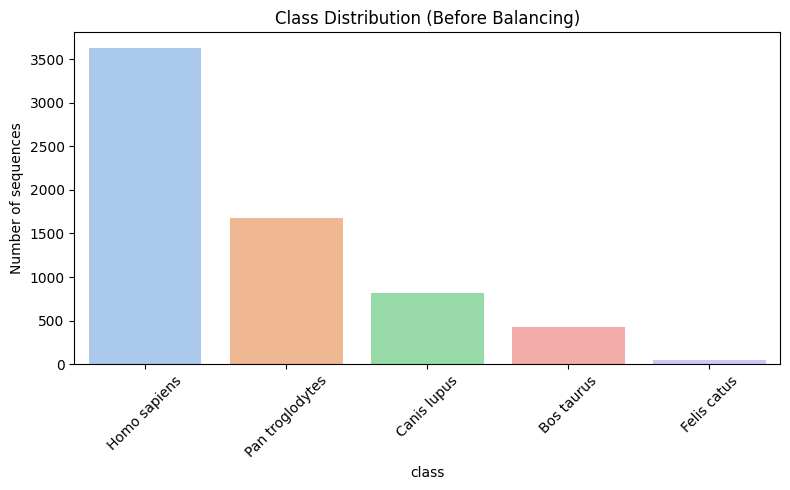

In [34]:
# =====================================================================
# 8. Class Distribution Visualization (Before Balancing)
# =====================================================================
class_counts = DNA['class'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="pastel", legend=False)
plt.title("Class Distribution (Before Balancing)")
plt.ylabel("Number of sequences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/class_distribution_before.png", dpi=150)





### Three Findings That Change Model Design

1. **Human and chimpanzee sequences are the most likely confusion pair.** Pan troglodytes and Homo sapiens are evolutionarily close (>98% genome-level similarity), so their k-mer and base-composition profiles overlap more than with dog, cat, or cow. Expect the model to confuse these two classes specifically, not confusion spread evenly across all five.
2. **Sequence length varies a lot within and across classes**, and a nontrivial share of sequences sit far outside the interquartile range (see outlier analysis below). A fixed-length input (e.g. for a CNN/LSTM) needs a truncation/padding strategy chosen from this distribution, not an arbitrary constant — using the raw max length would waste compute on padding for the majority of short sequences.
3. **GC content and top k-mer frequencies differ measurably by species** (see plots below), which is encouraging: it means the raw sequence content itself carries a distinguishable class signal, so k-mer-based or one-hot encoded models are the right family of approach here, rather than needing hand-engineered features.


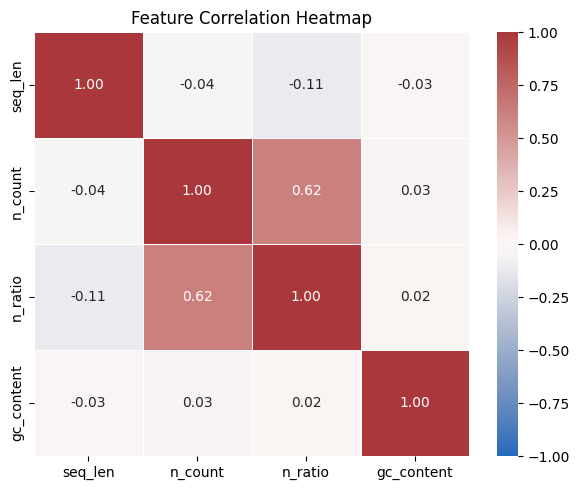

In [35]:
numeric_cols = ['seq_len', 'n_count', 'n_ratio', 'gc_content']
corr = DNA[numeric_cols].corr()


plt.figure(figsize=(6, 5))
sns.heatmap(
    corr, 
    annot=True, 
    cmap="vlag", 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/correlation_heatmap.png", dpi=150)
plt.show()


Outlier count (by sequence length, IQR method) per class:
  Bos taurus: 65
  Canis lupus: 35
  Felis catus: 2
  Homo sapiens: 230
  Pan troglodytes: 82


<Figure size 700x400 with 0 Axes>

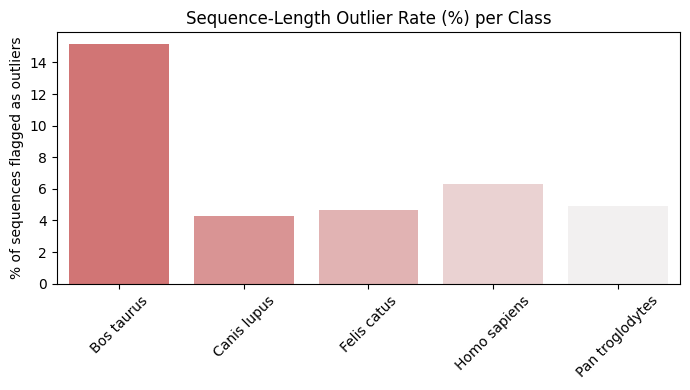

In [36]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_summary = {}
for cls, group in DNA.groupby('class'):
    mask = iqr_outliers(group['seq_len'])
    outlier_summary[cls] = int(mask.sum())

print("Outlier count (by sequence length, IQR method) per class:")
for cls, count in outlier_summary.items():
    print(f"  {cls}: {count}")


outlier_rate = {cls: outlier_summary[cls] / len(group) * 100
                for cls, group in DNA.groupby('class')}
plt.figure(figsize=(7, 4))
pastel_gradient = sns.light_palette("#e06666", n_colors=len(outlier_rate), reverse=True)

plt.figure(figsize=(7, 4))
sns.barplot(
    x=list(outlier_rate.keys()), 
    y=list(outlier_rate.values()), 
    hue=list(outlier_rate.keys()), 
    palette=pastel_gradient, 
    legend=False
)
plt.title("Sequence-Length Outlier Rate (%) per Class")
plt.ylabel("% of sequences flagged as outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/outlier_rate_bar.png", dpi=150)
plt.show()

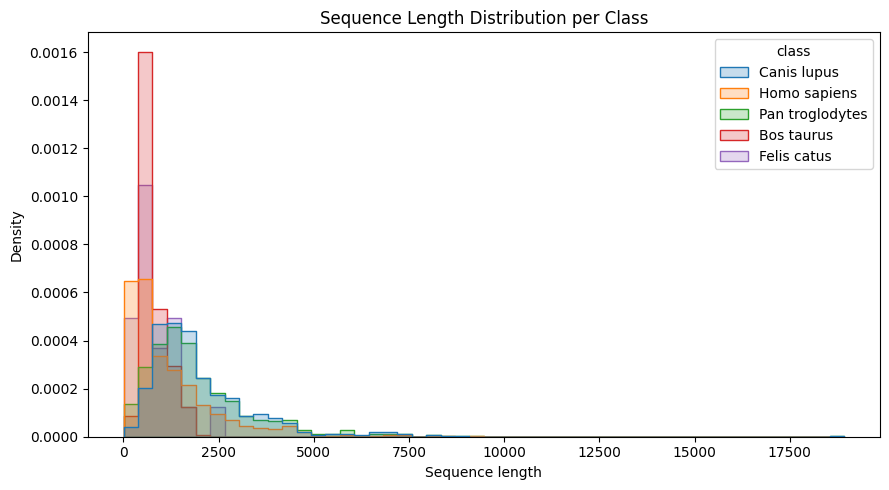

In [37]:
plt.figure(figsize=(9, 5))
sns.histplot(data=DNA, x='seq_len', hue='class', bins=50, element='step', stat='density', common_norm=False)
plt.title("Sequence Length Distribution per Class")
plt.xlabel("Sequence length")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/seq_len_distribution.png", dpi=150)
plt.show()

              class kmer      freq
0        Bos taurus  ---  0.077340
1        Bos taurus  AAT  0.028070
2        Bos taurus  ATT  0.026074
3        Bos taurus  ATA  0.025998
4        Bos taurus  CTA  0.024936
5        Bos taurus  CCC  0.024320
6        Bos taurus  TAA  0.024002
7        Bos taurus  TTC  0.023559
8        Bos taurus  AAC  0.022932
9        Bos taurus  CCT  0.022179
10      Canis lupus  CTG  0.028601
11      Canis lupus  CAG  0.027902
12      Canis lupus  TGG  0.025036
13      Canis lupus  CCA  0.024649
14      Canis lupus  GGA  0.023389
15      Canis lupus  GCC  0.023043
16      Canis lupus  AGA  0.022750
17      Canis lupus  CCC  0.022726
18      Canis lupus  CCT  0.022293
19      Canis lupus  GAG  0.022189
20      Felis catus  ---  0.292211
21      Felis catus  CTA  0.020699
22      Felis catus  TAT  0.019447
23      Felis catus  CCT  0.018621
24      Felis catus  ACT  0.018435
25      Felis catus  ATT  0.018168
26      Felis catus  TTA  0.017076
27      Felis catus 

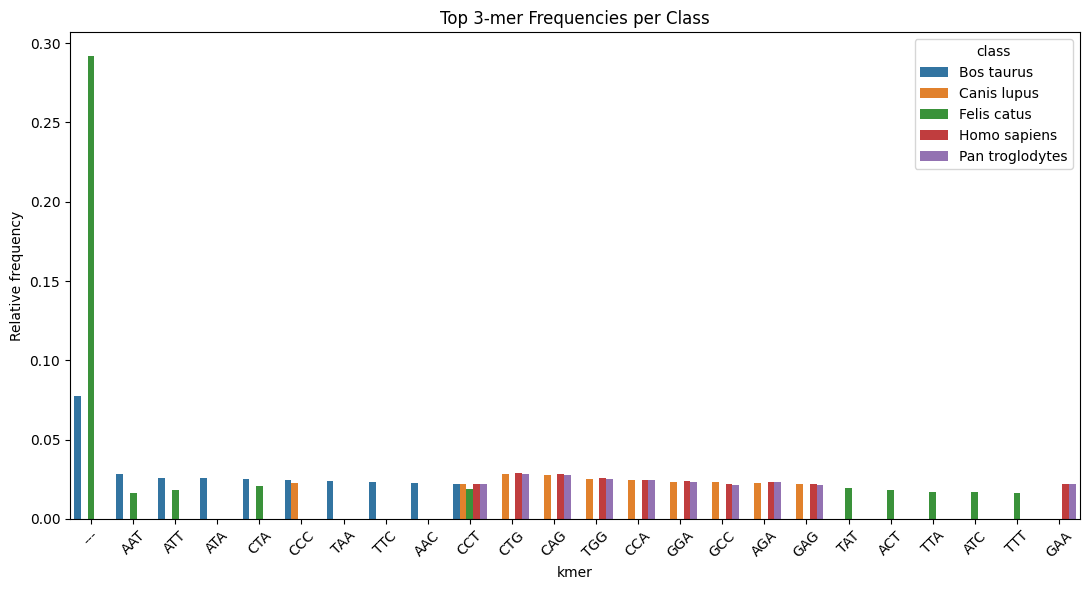

In [38]:
K = 3
def kmer_counts(seq, k=K):
    seq = seq.upper()
    return Counter(seq[i:i+k] for i in range(len(seq) - k + 1) if 'N' not in seq[i:i+k])

kmer_by_class = {}
for cls, group in DNA.groupby('class'):
    total = Counter()
    for seq in group['sequence']:
        total.update(kmer_counts(seq))
    kmer_by_class[cls] = total

top_kmer_rows = []
for cls, counts in kmer_by_class.items():
    total_count = sum(counts.values())
    for kmer, c in counts.most_common(10):
        top_kmer_rows.append({'class': cls, 'kmer': kmer, 'freq': c / total_count})

kmer_df = pd.DataFrame(top_kmer_rows)
print(kmer_df)

plt.figure(figsize=(11, 6))
sns.barplot(data=kmer_df, x='kmer', y='freq', hue='class')
plt.title(f"Top {K}-mer Frequencies per Class")
plt.ylabel("Relative frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/kmer_frequency.png", dpi=150)
plt.show()

                        A         C         G         T
class                                                  
Bos taurus       0.270102  0.259062  0.153956  0.264751
Canis lupus      0.243535  0.273846  0.267912  0.214485
Felis catus      0.223879  0.214321  0.137614  0.251873
Homo sapiens     0.250419  0.264521  0.266717  0.217917
Pan troglodytes  0.252252  0.264047  0.263655  0.220032


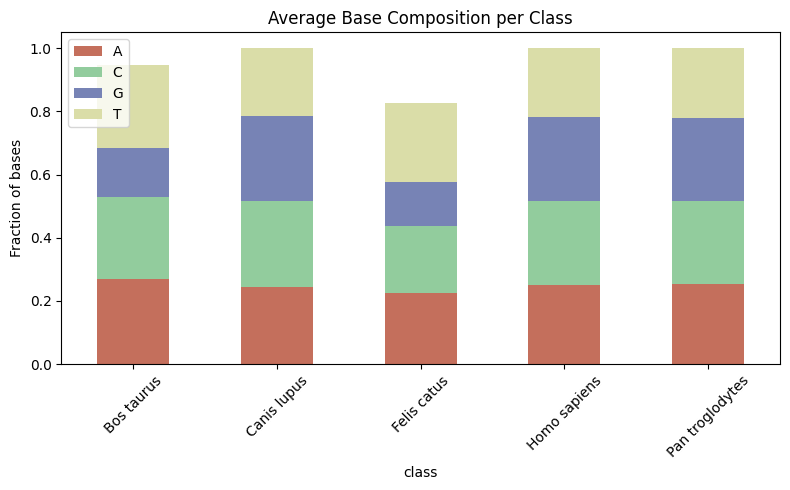

In [39]:
bases = ['A', 'C', 'G', 'T']

def base_fractions(seq):
    seq = seq.upper()
    length = len(seq) if len(seq) > 0 else 1
    return pd.Series({b: seq.count(b) / length for b in bases})

base_df = DNA['sequence'].apply(base_fractions)
base_df['class'] = DNA['class'].values

base_comp_by_class = base_df.groupby('class')[bases].mean()
print(base_comp_by_class)

# Map each base to a custom color (Hex, RGB, or Matplotlib color names)
base_colors = {
    'A': "#C46F5C",  
    'C': "#92CC9D",  
    'G': "#7783B5",  
    'T': "#DADDA8"   
}

base_comp_by_class.plot(
    kind='bar', 
    stacked=True, 
    figsize=(8, 5), 
    color=base_colors
)
plt.title("Average Base Composition per Class")
plt.ylabel("Fraction of bases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/base_composition.png", dpi=150)
plt.show()



In [40]:
# =====================================================================
# 9. Train/Test Split, Augmentation, and Balancing
# =====================================================================

train_df, temp_df = train_test_split(
    DNA, test_size=0.3, stratify=DNA['class'], random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['class'], random_state=RANDOM_STATE
)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain class balance:\n", train_df['class'].value_counts(normalize=True))
print("\nVal class balance:\n", val_df['class'].value_counts(normalize=True))
print("\nTest class balance:\n", test_df['class'].value_counts(normalize=True))

def sliding_window_augment(df, window_size=WINDOW_SIZE, stride=WINDOW_STRIDE):
    """Chop each sequence into overlapping windows. Sequences shorter
    than window_size are kept as-is (single row)."""
    rows = []
    for _, row in df.iterrows():
        seq, label = row['sequence'], row['class']
        if len(seq) <= window_size:
            rows.append({'sequence': seq, 'class': label})
            continue
        for start in range(0, len(seq) - window_size + 1, stride):
            rows.append({'sequence': seq[start:start + window_size], 'class': label})
    return pd.DataFrame(rows)

Train shape: (4613, 6)
Val shape: (988, 6)
Test shape: (989, 6)

Train class balance:
 class
Homo sapiens       0.550618
Pan troglodytes    0.254065
Canis lupus        0.123781
Bos taurus         0.065034
Felis catus        0.006503
Name: proportion, dtype: float64

Val class balance:
 class
Homo sapiens       0.550607
Pan troglodytes    0.254049
Canis lupus        0.123482
Bos taurus         0.064777
Felis catus        0.007085
Name: proportion, dtype: float64

Test class balance:
 class
Homo sapiens       0.550051
Pan troglodytes    0.253792
Canis lupus        0.124368
Bos taurus         0.065723
Felis catus        0.006067
Name: proportion, dtype: float64


### Train / Validation / Test Split Plan

**Approach: stratified random split, 70% train / 15% val / 15% test.**

- **Not time-based**: these are standalone gene/barcode sequence records with no temporal ordering or collection timestamp — a time-based split isn't meaningful here.
- **Not grouped by individual/patient**: the data has no specimen or individual-organism identifier, only a species label. Grouping by individual isn't possible with the available metadata (noted as a limitation in the Dataset Card above) — this is a residual leakage risk worth flagging rather than a solved problem.
- **Stratified is essential** because of the severe class imbalance (0.7%–54% across classes): a plain random split risks near-zero or zero Felis catus examples landing in the smaller val/test folds, making evaluation on that class meaningless.
- **Augmentation ordering**: the sliding-window augmentation is applied *only after* the split and *only to the training set*. This avoids leaking overlapping windows of the same source sequence across train/val/test, which would otherwise inflate validation/test performance artificially.

In [41]:
counts = train_df['class'].value_counts()
majority_class = counts.idxmax()
 
augmented_parts = []
for cls, cnt in counts.items():
    subset = train_df[train_df['class'] == cls]
    if cls == majority_class:
        # Cap the majority class instead of augmenting it
        capped = subset.sample(n=min(MAJORITY_CAP, len(subset)), random_state=RANDOM_STATE)
        augmented_parts.append(capped)
    else:
        aug = sliding_window_augment(subset)
        # don't let augmentation wildly overshoot the majority cap either
        if len(aug) > MAJORITY_CAP:
            aug = aug.sample(n=MAJORITY_CAP, random_state=RANDOM_STATE)
        augmented_parts.append(aug)
 
train_balanced = pd.concat(augmented_parts, ignore_index=True)
train_balanced = train_balanced.drop_duplicates().reset_index(drop=True)
 
print("Balanced train class distribution:")
print(train_balanced['class'].value_counts())

Balanced train class distribution:
class
Homo sapiens       1500
Canis lupus        1496
Pan troglodytes    1489
Bos taurus          850
Felis catus         349
Name: count, dtype: int64


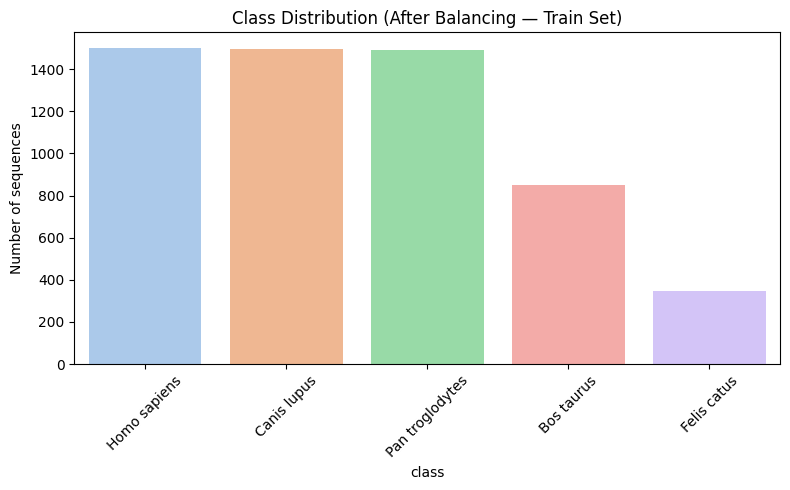

In [42]:
train_balanced.to_csv(f"{OUT_DIR}/train_balanced.csv", index=False)
val_df.to_csv(f"{OUT_DIR}/val_final.csv", index=False)
test_df.to_csv(f"{OUT_DIR}/test_final.csv", index=False)
DNA.to_csv(f"{OUT_DIR}/all_combined_dna_cleaned.csv", index=False)

plt.figure(figsize=(8, 5))
final_counts = train_balanced['class'].value_counts()
sns.barplot(x=final_counts.index, y=final_counts.values, hue=final_counts.index, palette="pastel", legend=False)
plt.title("Class Distribution (After Balancing — Train Set)")
plt.ylabel("Number of sequences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/class_distribution_after.png", dpi=150)
plt.show()